# 07 — EXPLORATORY: pitch-level value model

**Not pre-registered.** Added 2026-10-01 after H3 (fastball velocity) was named dominant. It asks how much each
mph is worth on a single pitch, holding the pitch's other traits, its location and the count fixed.

**Model A: four-seam fastballs** (Sasaki + Yamamoto). Linear regression of each pitch's run value on its physical
traits, plus location, count, batter handedness and a pitcher indicator.
**Model B: Sasaki's splitters.** Does a splitter do better on days his fastball is harder? Same setup, with that
game's average four-seam velocity as the key feature. This tests the owner's view that a slow fastball hurt the splitter.

**What the regression does, in plain terms:** it fits one straight-line effect per feature at the same time. So
the velocity coefficient means "change in run value per +1 mph when movement, spin, location and count are the same."
**Assumptions and what can break it:** effects are assumed linear and additive (no interactions); features that
move together, like velocity and spin, share credit unstably; and per-pitch run value is very noisy (R² will be
tiny), so only effects summed over many pitches mean anything. Standard errors are clustered by game, because
pitches from the same day aren't independent.

Outcome sign: `rv100` = −delta_run_exp × 100 = runs saved per 100 pitches (positive = good for the pitcher).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

RAW = Path("../data/raw")
FIG = Path("../figures")
PROC = Path("../data/processed")
pd.set_option("display.width", 200)
WHIFF = {"swinging_strike", "swinging_strike_blocked", "missed_bunt"}
SWING = WHIFF | {"foul", "foul_tip", "foul_bunt", "bunt_foul_tip", "hit_into_play"}

In [2]:
def load(name, seasons):
    d = pd.concat([pd.read_csv(RAW / f"{name}_statcast_mlb_{y}.csv", low_memory=False).assign(season=y)
                   for y in seasons], ignore_index=True)
    d = d[(d.game_type != "S") & ~((d.season == 2026) & d.game_type.isin(["F", "D", "L", "W"]))]
    d["pa_id"] = d.game_pk.astype(str) + "_" + d.at_bat_number.astype(str)
    d = d[~d.pa_id.isin(d.loc[d.events == "intent_walk", "pa_id"])]
    d = d[d.description != "pitchout"]
    d["pitcher_name"] = name
    return d

d = pd.concat([load("sasaki", [2025, 2026]), load("yamamoto", [2024, 2025, 2026])], ignore_index=True)
d["game_ff_velo"] = d.game_pk.map(d[d.pitch_type == "FF"].groupby("game_pk").release_speed.mean())
d["rv100"] = -d.delta_run_exp * 100
d["ivb"] = d.pfx_z * 12
d["arm_side_break"] = -d.pfx_x * 12  # both pitchers are RHP: positive = arm side
half_h = (d.sz_top - d.sz_bot) / 2
d["z_rel"] = (d.plate_z - (d.sz_top + d.sz_bot) / 2) / half_h  # 0 = zone middle, ±1 = top/bottom edge
d["x_rel"] = d.plate_x / ((17 / 2) / 12)
d["count"] = d.balls.astype(str) + "-" + d.strikes.astype(str)
d["same_side"] = (d.stand == d.p_throws).astype(int)
d["swing"] = d.description.isin(SWING)
d["whiff"] = d.description.isin(WHIFF).astype(int)
FEATS = ["release_speed", "ivb", "arm_side_break", "release_spin_rate", "release_extension", "release_pos_z"]
LOC = "x_rel + I(x_rel**2) + z_rel + I(z_rel**2) + C(count) + same_side"
ff = d[(d.pitch_type == "FF")].dropna(subset=FEATS + ["x_rel", "z_rel", "rv100"]).copy()
ff.groupby("pitcher_name").size()

/var/folders/sm/_ttyl33555v_1wtcfv790wcr0000gn/T/ipykernel_16123/2130085109.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d = pd.concat([pd.read_csv(RAW / f"{name}_statcast_mlb_{y}.csv", low_memory=False).assign(season=y)
/var/folders/sm/_ttyl33555v_1wtcfv790wcr0000gn/T/ipykernel_16123/2130085109.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d = pd.concat([pd.read_csv(RAW / f"{name}_statcast_mlb_{y}.csv", low_memory=False).assign(season=y)
/var/folders/sm/_ttyl33555v_1wtcfv790wcr0000gn/T/ipykernel_16123/2130085109.py

/var/folders/sm/_ttyl33555v_1wtcfv790wcr0000gn/T/ipykernel_16123/2130085109.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d = pd.concat([pd.read_csv(RAW / f"{name}_statcast_mlb_{y}.csv", low_memory=False).assign(season=y)
/var/folders/sm/_ttyl33555v_1wtcfv790wcr0000gn/T/ipykernel_16123/2130085109.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d["pa_id"] = d.game_pk.astype(str) + "_" + d.at_bat_number.astype(str)
/var/folders/sm/_ttyl33555v_1wtcfv790wcr0000gn/T/ipykernel_16123/2130085109.py:8: PerformanceWarning: DataF

pitcher_name
sasaki      1275
yamamoto    2565
dtype: int64

## Model A — four-seam run value

In [3]:
def fit_ols(df, formula):
    return smf.ols(formula, data=df).fit(cov_type="cluster", cov_kwds={"groups": df.game_pk})

def tidy(fit, terms, label):
    ci = fit.conf_int()
    return pd.DataFrame({"model": label, "term": terms, "coef": fit.params[terms].values,
                         "ci_lo": ci.loc[terms, 0].values, "ci_hi": ci.loc[terms, 1].values,
                         "p": fit.pvalues[terms].values}).round(4)

form_raw = "rv100 ~ " + " + ".join(FEATS) + " + " + LOC
A_pooled = fit_ols(ff, form_raw + " + C(pitcher_name)")
A_sasaki = fit_ols(ff[ff.pitcher_name == "sasaki"], form_raw)
A_yam = fit_ols(ff[ff.pitcher_name == "yamamoto"], form_raw)
modelA = pd.concat([tidy(A_pooled, FEATS, "pooled (pitcher indicator)"), tidy(A_sasaki, FEATS, "Sasaki only"),
                    tidy(A_yam, FEATS, "Yamamoto only")])
print(f"R²: pooled {A_pooled.rsquared:.3f}, Sasaki {A_sasaki.rsquared:.3f}, Yamamoto {A_yam.rsquared:.3f} "
      f"| pitches: {int(A_pooled.nobs)}, {int(A_sasaki.nobs)}, {int(A_yam.nobs)}")
modelA[modelA.term == "release_speed"]

R²: pooled 0.030, Sasaki 0.035, Yamamoto 0.041 | pitches: 3840, 1275, 2565


,model,term,coef,ci_lo,ci_hi,p
0,pooled (pitcher indicator),release_speed,-0.1615,-0.7857,0.4627,0.6121
0,Sasaki only,release_speed,0.0188,-1.0218,1.0593,0.9718
0,Yamamoto only,release_speed,-0.2560,-0.9427,0.4307,0.4650


### Feature attribution: standardized coefficients (runs saved per 100 pitches per 1 SD of each trait)
Each trait is put on the same scale (1 standard deviation), so the coefficients show which trait matters most.

In [4]:
z = ff.copy()
for f in FEATS:
    z[f] = (z[f] - z[f].mean()) / z[f].std()
A_std = fit_ols(z, form_raw + " + C(pitcher_name)")
attr = tidy(A_std, FEATS, "pooled, standardized").assign(sd_of_trait=[round(ff[f].std(), 2) for f in FEATS])
attr.sort_values("coef", key=abs, ascending=False)

,model,term,coef,ci_lo,ci_hi,p,sd_of_trait
5,"pooled, standardized",release_pos_z,-1.0926,-3.4250,1.2398,0.3585,0.38
2,"pooled, standardized",arm_side_break,0.5947,-0.3859,1.5753,0.2346,2.37
0,"pooled, standardized",release_speed,-0.2457,-1.1955,0.7041,0.6121,1.52
1,"pooled, standardized",ivb,0.2180,-0.5265,0.9625,0.5660,1.68
4,"pooled, standardized",release_extension,0.0983,-1.2959,1.4925,0.8901,0.30
3,"pooled, standardized",release_spin_rate,-0.0716,-0.9153,0.7720,0.8678,123.96


### Whiff on swings (linear probability model, percentage points per +1 mph)

In [5]:
sw = ff[ff.swing].copy()
sw["whiff100"] = sw.whiff * 100
W_pooled = fit_ols(sw, "whiff100 ~ " + " + ".join(FEATS) + " + " + LOC + " + C(pitcher_name)")
W_sasaki = fit_ols(sw[sw.pitcher_name == "sasaki"], "whiff100 ~ " + " + ".join(FEATS) + " + " + LOC)
whiff = pd.concat([tidy(W_pooled, ["release_speed"], "pooled"), tidy(W_sasaki, ["release_speed"], "Sasaki only")])
whiff

,model,term,coef,ci_lo,ci_hi,p
0,pooled,release_speed,2.2725,0.8448,3.7003,0.0018
0,Sasaki only,release_speed,1.8329,0.1624,3.5033,0.0315


### What the velocity coefficient implies over a season
Sasaki's 2026 starts averaged 97.8 mph on ~860 four-seamers; 2025 starts averaged 96.0 on ~300.

In [6]:
b, lo, hi = A_sasaki.params["release_speed"], *A_sasaki.conf_int().loc["release_speed"]
for mph in [1.0, 1.8]:
    print(f"+{mph} mph on 860 four-seamers ≈ {b * mph * 8.6:+.1f} runs saved  [{lo * mph * 8.6:+.1f}, {hi * mph * 8.6:+.1f}] (Sasaki-only model)")

+1.0 mph on 860 four-seamers ≈ +0.2 runs saved  [-8.8, +9.1] (Sasaki-only model)
+1.8 mph on 860 four-seamers ≈ +0.3 runs saved  [-15.8, +16.4] (Sasaki-only model)


## Model B — Sasaki splitters: does a harder fastball that day help the splitter?
Splitters = FO + FS, with a pitch-type indicator so the two shapes aren't mixed. The key feature is
`game_ff_velo` (that game's average four-seam velocity). The splitter's own velocity and movement are held fixed.

In [7]:
SPL = ["release_speed", "ivb", "arm_side_break", "release_spin_rate"]
spl = d[(d.pitcher_name == "sasaki") & d.pitch_type.isin(["FO", "FS"])].dropna(subset=SPL + ["x_rel", "z_rel", "rv100", "game_ff_velo"]).copy()
B_rv = fit_ols(spl, "rv100 ~ game_ff_velo + " + " + ".join(SPL) + " + C(pitch_type) + " + LOC)
spl_sw = spl[spl.swing].assign(whiff100=lambda t: t.whiff * 100)
B_wh = fit_ols(spl_sw, "whiff100 ~ game_ff_velo + " + " + ".join(SPL) + " + C(pitch_type) + " + LOC)
ch = spl[spl.zone >= 11].assign(chase100=lambda t: t.swing.astype(int) * 100)
B_ch = fit_ols(ch, "chase100 ~ game_ff_velo + " + " + ".join(SPL) + " + C(pitch_type) + " + LOC)
modelB = pd.concat([tidy(B_rv, ["game_ff_velo"], f"splitter run value /100 (n={int(B_rv.nobs)})"),
                    tidy(B_wh, ["game_ff_velo"], f"splitter whiff % on swings (n={int(B_wh.nobs)})"),
                    tidy(B_ch, ["game_ff_velo"], f"splitter chase % out of zone (n={int(B_ch.nobs)})")])
modelB

,model,term,coef,ci_lo,ci_hi,p
0,splitter run value /100 (n=1051),game_ff_velo,0.3037,-0.7386,1.3461,0.5679
0,splitter whiff % on swings (n=520),game_ff_velo,2.1458,-1.1413,5.4328,0.2007
0,splitter chase % out of zone (n=674),game_ff_velo,0.9198,-3.2437,5.0833,0.6650


In [8]:
pd.concat([modelA, attr, whiff, modelB]).to_csv(PROC / "s7_pitch_model.csv", index=False)

## Figure — standardized four-seam trait effects (pooled)

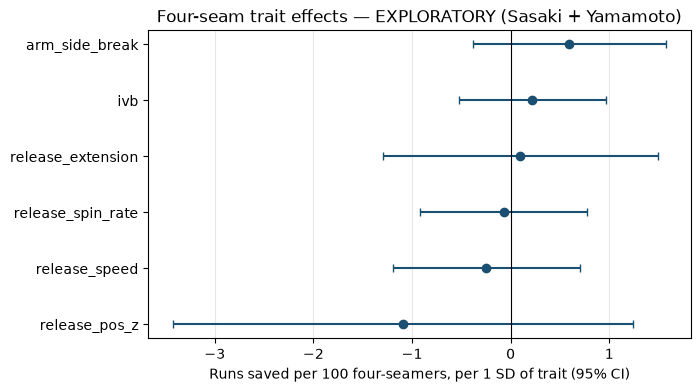

In [9]:
a = attr.sort_values("coef")
fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(a.coef, range(len(a)), xerr=[a.coef - a.ci_lo, a.ci_hi - a.coef], fmt="o", color="#1b4f72", capsize=3)
ax.axvline(0, color="black", lw=0.8)
ax.set_yticks(range(len(a)))
ax.set_yticklabels(a.term)
ax.set_xlabel("Runs saved per 100 four-seamers, per 1 SD of trait (95% CI)")
ax.set_title("Four-seam trait effects — EXPLORATORY (Sasaki + Yamamoto)")
ax.grid(axis="x", alpha=0.3)
fig.savefig(FIG / "s7_ff_trait_effects.png", dpi=150, bbox_inches="tight")